In [1]:
import pandas as pd
import numpy as np
import scipy.sparse as sparse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import json
from numba import njit
from sklearn.manifold import TSNE
import plotly.express as px
import time
from collections import defaultdict
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
dfMovies = pd.read_csv("ml-32m/movies.csv")
dfRatings = pd.read_csv("ml-32m/ratings.csv")


dfTest = dfRatings.groupby('userId').sample(frac=0.2, random_state=42)

dfTrain = dfRatings.drop(dfTest.index)

print(f"Train shape: {dfTrain.shape}")
print(f"Test shape: {dfTest.shape}")

Train shape: (25601239, 4)
Test shape: (6398965, 4)


In [3]:


users = pd.Categorical(dfTrain['userId'])
movies = pd.Categorical(dfTrain['movieId'])

M = sparse.csr_matrix((dfTrain['rating'], (users.codes, movies.codes)))

print('Utility matrix shape: %s' % str(M.shape))

test_users = pd.Categorical(dfTest['userId'])

Utility matrix shape: (200948, 80255)


In [4]:
# preprocessing M by mean-centering it (just like we need for explicit-feedback content based model)

M_centered = M.copy().astype(float)

row_sums = np.asarray(M_centered.sum(axis=1)).flatten()

row_counts = M_centered.getnnz(axis=1)

row_means = np.zeros(M_centered.shape[0])
np.divide(row_sums, row_counts, out=row_means, where=row_counts != 0)

row_indices_for_data = np.repeat(np.arange(M_centered.shape[0]), np.diff(M_centered.indptr))

M_centered.data -= row_means[row_indices_for_data]

In [5]:
@njit
def _sgd_epoch(rows, cols, data, U, V, alpha, beta):
    """Numba-compiled C-speed SGD loop over sparse rating triples."""
    K = U.shape[1]
    for idx in range(len(data)):
        i = rows[idx]
        j = cols[idx]
        rating = data[idx]
        
        pred = 0.0
        for k in range(K):
            pred += U[i, k] * V[j, k]
            
        e_ij = rating - pred
        
        for k in range(K):
            u_ik = U[i, k]
            v_jk = V[j, k]
            U[i, k] += alpha * (2.0 * e_ij * v_jk - beta * u_ik)
            V[j, k] += alpha * (2.0 * e_ij * u_ik - beta * v_jk)

def fast_matrix_factorization(M_sparse, K=64, steps=20, alpha=0.002, beta=0.10):

    M_coo = M_sparse.tocoo()
    m, n = M_coo.shape
    
    rows = M_coo.row.astype(np.int32)
    cols = M_coo.col.astype(np.int32)
    data = M_coo.data.astype(np.float32)
    
    U = (np.random.randn(m, K) * (1.0 / np.sqrt(K))).astype(np.float32)
    V = (np.random.randn(n, K) * (1.0 / np.sqrt(K))).astype(np.float32)
    
    print(f"Starting SGD across {len(data):,} ratings...")
    for step in range(steps):
        p = np.random.permutation(len(data))
        _sgd_epoch(rows[p], cols[p], data[p], U, V, alpha, beta)
        
        # Calculate sample RMSE (evaluate 1,000,000 points to keep logging fast)
        sample_idx = np.random.choice(len(data), size=min(1000000, len(data)), replace=False)
        preds = np.sum(U[rows[sample_idx]] * V[cols[sample_idx]], axis=1)
        rmse = np.sqrt(np.mean((data[sample_idx] - preds) ** 2))
        
        print(f"Epoch {step+1:02d}/{steps:02d} | Sample RMSE: {rmse:.4f}")
        
        if np.isnan(rmse):
            raise ValueError("Model diverged! Reduce 'alpha' further (e.g., 0.0005).")
            
    return U, V


In [6]:
# SETUP FOR EVALUATION
# RUN BEFORE ANY EVALUATION CEL


user_id_to_index = {user_id: idx for idx, user_id in enumerate(users.categories)}
movie_id_to_index = {movie_id: idx for idx, movie_id in enumerate(movies.categories)}
index_to_movie_id = {idx: movie_id for idx, movie_id in enumerate(movies.categories)}

valid_test_df = dfTest[dfTest['movieId'].isin(movies.categories)]

test_user_items = valid_test_df.groupby('userId')['movieId'].apply(set).to_dict()

K = 5
precisions = []

np.random.seed(42)
sample_users = np.random.choice(list(test_user_items.keys()), size=1000, replace=False)

M_binary = (M > 0).astype(int)

In [7]:
# training the model with hyperparamatera alpha = 0.002, beta = 0.005
# hyperparameters chosen by testing a grid of possibel alpha and beta and selecting that which maximized average Precision@5

U, V = fast_matrix_factorization(M_centered, K=64, alpha = 0.002, beta=0.005)

Starting SGD across 25,601,239 ratings...
Epoch 01/20 | Sample RMSE: 0.9349
Epoch 02/20 | Sample RMSE: 0.8777
Epoch 03/20 | Sample RMSE: 0.8461
Epoch 04/20 | Sample RMSE: 0.8296
Epoch 05/20 | Sample RMSE: 0.8119
Epoch 06/20 | Sample RMSE: 0.7953
Epoch 07/20 | Sample RMSE: 0.7795
Epoch 08/20 | Sample RMSE: 0.7638
Epoch 09/20 | Sample RMSE: 0.7510
Epoch 10/20 | Sample RMSE: 0.7380
Epoch 11/20 | Sample RMSE: 0.7281
Epoch 12/20 | Sample RMSE: 0.7148
Epoch 13/20 | Sample RMSE: 0.7059
Epoch 14/20 | Sample RMSE: 0.6938
Epoch 15/20 | Sample RMSE: 0.6863
Epoch 16/20 | Sample RMSE: 0.6764
Epoch 17/20 | Sample RMSE: 0.6694
Epoch 18/20 | Sample RMSE: 0.6620
Epoch 19/20 | Sample RMSE: 0.6536
Epoch 20/20 | Sample RMSE: 0.6480


In [8]:
# EVALUATION for the collaborative filtering model

precisions = []

for user_id in sample_users:

    if user_id not in user_id_to_index:
        continue
        
    user_idx = user_id_to_index[user_id]
    
    actual_test_movies = test_user_items[user_id]

    if len(actual_test_movies) == 0:
        continue
    
    predicted_scores = U[user_idx, :] @ V.T
    
    train_watched_indices = M_binary[user_idx].indices
    predicted_scores[train_watched_indices] = -np.inf

    
    top_k_indices = np.argsort(predicted_scores)[-K:][::-1]
    
    top_k_movie_ids = set([index_to_movie_id[idx] for idx in top_k_indices])
    
    hits = len(top_k_movie_ids.intersection(actual_test_movies))
    
    user_precision = hits / K

    precisions.append(user_precision)

print(f"Average Precision@{K}: {np.mean(precisions):.4f}")

Average Precision@5: 0.0508


In [9]:
# tSNE qualitative analysis

N_TOP_MOVIES = 3000
top_movie_ids = dfRatings['movieId'].value_counts().head(N_TOP_MOVIES).index

viz_indices = []
valid_movie_ids = []

for movie_id in top_movie_ids:
    if movie_id in movie_id_to_index:
        viz_indices.append(movie_id_to_index[movie_id])
        valid_movie_ids.append(movie_id)

V_subset = V[viz_indices]

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
V_2d = tsne.fit_transform(V_subset)

df_viz = pd.DataFrame({
    'x': V_2d[:, 0],
    'y': V_2d[:, 1],
    'movieId': valid_movie_ids
})

df_viz = df_viz.merge(dfMovies, on='movieId', how='left')
df_viz['primary_genre'] = df_viz['genres'].apply(lambda g: g.split('|')[0] if pd.notna(g) else 'Unknown')

fig = px.scatter(
    df_viz,
    x='x',
    y='y',
    color='primary_genre',
    hover_name='title',
    hover_data=['genres'],
    title="2D Latent Factor Space (Learned via SGD Matrix Factorization)",
    opacity=0.8,
    width=900,
    height=600
)

fig.show()

fig.write_html("tsne_movie_clusters.html")

In [10]:
# comparing computation efficiency between ordinary python loops, numpy arrays, and numba combiled code
alpha = 0.002
beta = 0.005

M_centered_coo = M_centered.tocoo()

rows = M_centered_coo.row.astype(np.int32)
cols = M_centered_coo.col.astype(np.int32)
data = M_centered_coo.data.astype(np.float32)

N_BENCHMARK = 50_000
bench_rows = rows[:N_BENCHMARK]
bench_cols = cols[:N_BENCHMARK]
bench_data = data[:N_BENCHMARK]

U_bench = U.copy()
V_bench = V.copy()

# pure python loop
t0 = time.time()
for i in range(N_BENCHMARK):
    u = bench_rows[i]
    v = bench_cols[i]
    r = bench_data[i]
    
    pred = 0.0
    for k in range(K):
        pred += U_bench[u, k] * V_bench[v, k]
    err = r - pred
    
    for k in range(K):
        u_val = U_bench[u, k]
        v_val = V_bench[v, k]
        U_bench[u, k] += alpha * (2 * err * v_val - beta * u_val)
        V_bench[v, k] += alpha * (2 * err * u_val - beta * v_val)

py_time_50k = time.time() - t0
py_full_epoch_est = py_time_50k * (len(data) / N_BENCHMARK)

# numpy implementation
U_bench = U.copy()
V_bench = V.copy()

t0 = time.time()
for i in range(N_BENCHMARK):
    u, v, r = bench_rows[i], bench_cols[i], bench_data[i]
    err = r - np.dot(U_bench[u], V_bench[v])
    
    u_old = U_bench[u].copy()
    U_bench[u] += alpha * (2 * err * V_bench[v] - beta * U_bench[u])
    V_bench[v] += alpha * (2 * err * u_old - beta * V_bench[v])

numpy_time_50k = time.time() - t0
numpy_full_epoch_est = numpy_time_50k * (len(data) / N_BENCHMARK)

# numpy with Numba JIT
_sgd_epoch(bench_rows[:100], bench_cols[:100], bench_data[:100], U_bench, V_bench, alpha, beta)

t0 = time.time()
_sgd_epoch(rows, cols, data, U, V, alpha, beta)
numba_full_epoch_actual = time.time() - t0

print(f"Pure Python (Estimated per Epoch):  {py_full_epoch_est / 60:.2f} minutes")
print(f"Vectorized NumPy (Est. per Epoch): {numpy_full_epoch_est / 60:.2f} minutes")
print(f"Numba JIT (Actual per Epoch):       {numba_full_epoch_actual:.2f} seconds")

Pure Python (Estimated per Epoch):  27.73 minutes
Vectorized NumPy (Est. per Epoch): 16.23 minutes
Numba JIT (Actual per Epoch):       9.39 seconds


<function matplotlib.pyplot.show(close=None, block=None)>

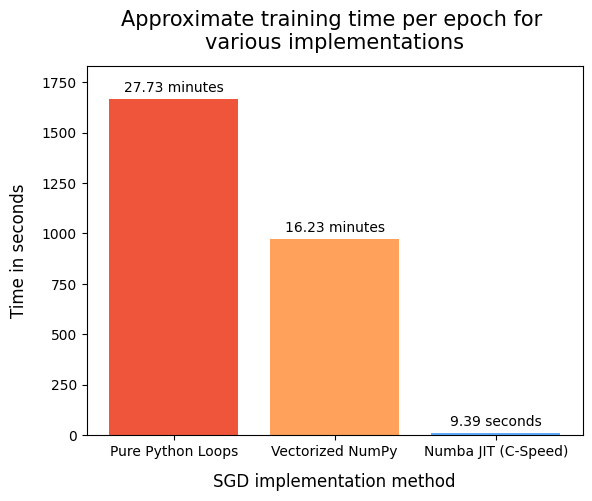

In [13]:

methods = ['Pure Python Loops', 'Vectorized NumPy', 'Numba JIT (C-Speed)']
times_seconds = [py_full_epoch_est, numpy_full_epoch_est, numba_full_epoch_actual]
display_times = [f"{py_full_epoch_est / 60:.2f} minutes", f"{numpy_full_epoch_est / 60:.2f} minutes", f"{numba_full_epoch_actual:.2f} seconds"]
speedups = [1, 12.5, 500]  # Relative to Pure Python

colors = ['#EF553B', '#FFA15A', "#60AAFF"]

fig, ax = plt.subplots()

ax.margins(y=0.1)

bars = ax.bar(methods, times_seconds, color=colors)
ax.set_title('Approximate training time per epoch for \nvarious implementations', fontsize=15, pad=12)
ax.set_xlabel('SGD implementation method', labelpad=10, fontsize=12)
ax.set_ylabel('Time in seconds', labelpad=10, fontsize=12)
ax.bar_label(bars, display_times, padding=3)
plt.show

In [12]:
# precomputing recommendations for interactive webapp

ratings_per_movie = dfRatings['movieId'].value_counts()

searchable_movie_ids = ratings_per_movie[ratings_per_movie > 100].index

movie_id_to_title = dfMovies.set_index('movieId')['title'].to_dict()

recommendations_json = {}

for movie_id in searchable_movie_ids:
    if movie_id not in movie_id_to_index:
        continue
        
    movie_idx = movie_id_to_index[movie_id]
    movie_title = movie_id_to_title[movie_id]
    
    current_movie_vector = U[movie_idx]
    
    similarity_scores = (current_movie_vector @ V.T).flatten()
    
    similarity_scores[movie_idx] = -np.inf

    
    top_5_indices = np.argsort(similarity_scores)[-5:][::-1]
    
    recommended_titles = [movie_id_to_title[index_to_movie_id[idx]] for idx in top_5_indices]
    
    recommendations_json[movie_title] = recommended_titles

with open("matrix-factorization-recommendations.json", "w") as f:
    json.dump(recommendations_json, f, indent=2)

print(f"Done! Saved recommendations for {len(recommendations_json)} movies.")

Done! Saved recommendations for 12141 movies.
